# TRABAJO SEMANAL N°0: Primeros pasos en la simulación
## Alumna: Maylen Monterde

### Consigna:
Se desea diseñar un generador de señales senoidales que permita parametrizar:
- Amplitud máxima de la senoidal [V]
- Valor medio [V]
- Frecuencia [Hz]
- Fase [rad]
- Cantidad de muestras
- Frecuencia de muestreo [Hz]

### Resolución:
1- Lo primero que se debe hacer es llamar a las librerías y definir las variables a utilizar. En este caso, esas variables (parámetros) van a ser fijos.

In [45]:
#Llamo a las librerias que voy a utilizar:
import numpy as np    
import matplotlib.pyplot as plt

#Parámetros (mis variables):    
Vmax = 4
Vmed = 0 #cuanto sube o baja respecto del eje x
ff = 500
phi = 0
N = 1000
fs = 1000

2- Creo la función observando que la señal senoidal tiene la forma:
$$X = Vmed + Vmax * sen(2*\pi*ff*t + \phi)$$
donde $t = N/fs$

In [46]:
#Me creo una función:           
"""Obs: dentro de los parámetros si no se ingresa nada, toma esos valores (ej: Vmax=1)"""

def funcion_sen( Vmax = 1, Vmed = 0, ff = 1, phi = 0, nn = N, fs = fs):
    tt = np.arange(nn)/fs #arranca en 0 y termina en N y eso se divide por la frecuencia de muestreo
    xx = Vmax * np.sin( 2*np.pi*ff*tt + phi ) + Vmed       
    return (tt,xx)

3- Llamo a la función y grafico

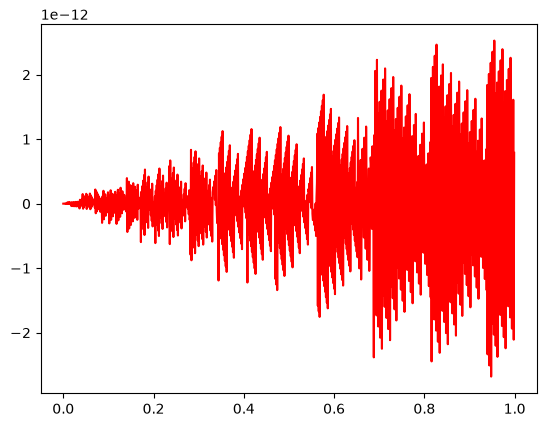

In [47]:
#Para la frecuencia ff=500:
ff = 500
tt, xx = funcion_sen(Vmax = Vmax, Vmed = Vmed, ff = ff, phi = phi, nn = N, fs = fs)
    
#Para graficar:
plt.figure(1)
plt.plot(tt, xx, label = "f=500", linestyle="-", color="red")

4- Voy modificando el valor de la frecuencia para analizar cómo cambian los gráficos:
- Si considero Frecuencia vale 999:

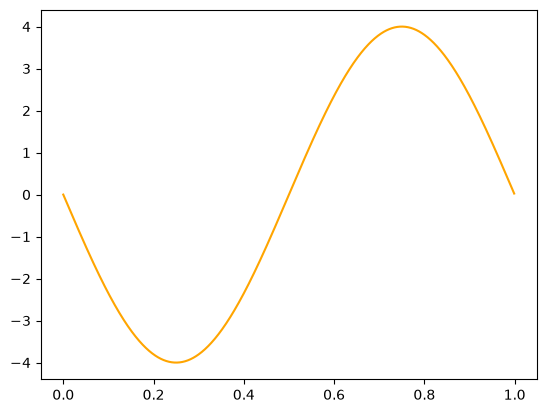

In [48]:
ff = 999
tt1, xx1 = funcion_sen(Vmax = Vmax, Vmed = Vmed, ff = ff, phi = phi, nn = N, fs = fs)
    
#Para graficar:
plt.figure(2)
plt.plot(tt1, xx1, label = "f=900", linestyle="-", color="orange")

- Si considero que la frecuencia vale 1001:

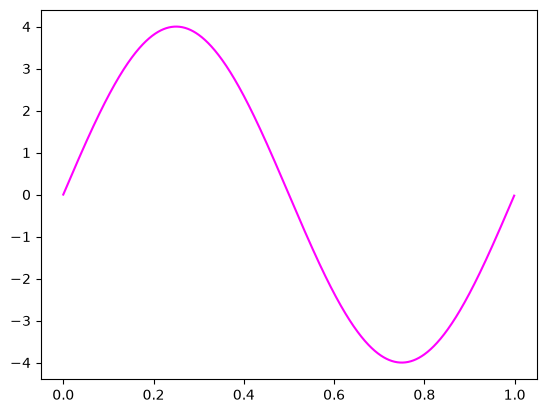

In [49]:
ff = 1001
tt2, xx2 = funcion_sen(Vmax = Vmax, Vmed = Vmed, ff = ff, phi = phi, nn = N, fs = fs)
    
#Para graficar:
plt.figure(3)
plt.plot(tt2, xx2, label = "f=1001", linestyle="-", color="magenta")

- Si considero que la frecuencia vale 2001:

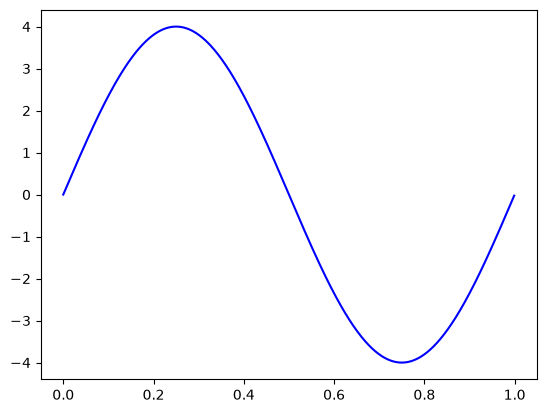

In [50]:
ff = 2001
tt3, xx3 = funcion_sen(Vmax = Vmax, Vmed = Vmed, ff = ff, phi = phi, nn = N, fs = fs)
    
#Para graficar:
plt.figure(4)
plt.plot(tt3, xx3, label = "f=500", linestyle="-", color="blue")

Entonces, juntando todos los graficos obtenemos:

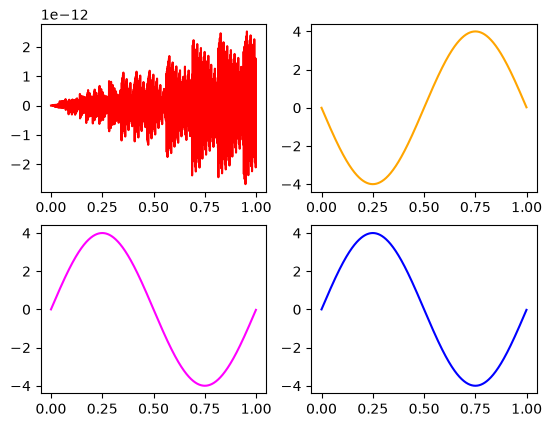

In [51]:
plt.figure (5)
plt.subplot(2,2,1)
plt.plot(tt, xx, label = "f=500", linestyle="-", color="red")

plt.subplot(2,2,2)
plt.plot(tt1, xx1, label = "f=900", linestyle="-", color="orange")

plt.subplot(2,2,3)
plt.plot(tt2, xx2, label = "f=1001", linestyle="-", color="magenta")

plt.subplot(2,2,4)
plt.plot(tt3, xx3, label = "f=2001", linestyle="-", color="blue")

Analizando las distintas frecuencias se puede obvervar que:
- A f=500Hz es justamente el límite de la frecuencia de Nyquist (ff=fs/2) dando que la frecuencia de muestreo es el doble de la frecuencia de la señal, se obtiene que se toma dos muestras por período y justamente caen en los cruces por cero de la función seno (debido a que la fase vale cero).
- Para las demás frecuencias estoy por encima de la frecuencia de Nyquist, entonces se verá una representación gráfica de múltiplos de esas frecuencias pero en un rango de 0 hasta la 500 Hz (frecuencia de Nyquist).
Además, se observa que para los valores "pegados" a la frecuencia de muestreo:
- f=999Hz : los fasores tienen el sentido correspondiente
- f=1001Hz : se invierten los sentidos de los fasores
  
Entonces, esto resulta como si la frecuencia de muestreo fuera un "espejo".

5- BONUS: 'agregar otra señal y analizarla' 
Para realizar esto consideré la función coseno. Entonces, defino una función con las variables y luego lo grafico. Además, consideré dos valores de frecuencia (uno 500 y el otro 5).

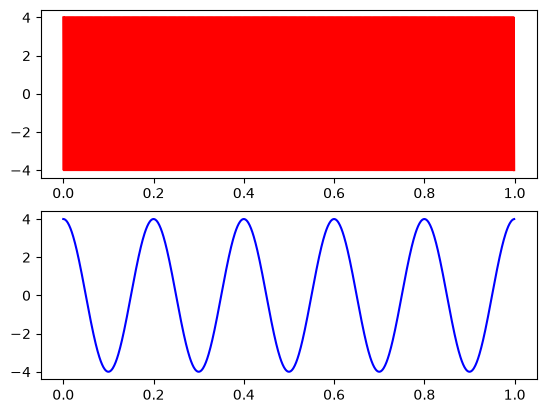

In [52]:
#Voy a considerar el coseno:
def funcion_cos( Vmax = 1, Vmed = 0, ff = 1, phi = 0, nn = N, fs = fs):

    tt4 = np.arange(nn)/fs #arranca en 0 y termina en N y eso se divide por la frecuencia de muestreo
    xx4 = Vmax * np.cos( 2*np.pi*ff*tt1 + phi ) + Vmed       
    return (tt4,xx4)

#Cambio la frecuencia a ff=500:
ff=500
tt4, xx4 = funcion_cos(Vmax = Vmax, Vmed = Vmed, ff = ff, phi = phi, nn = N, fs = fs)
    
#Para graficar:
plt.figure(6)
plt.subplot(2,1,1)
plt.plot(tt4, xx4, label = "f=500", linestyle="-", color="red")

#Cambio la frecuencia a ff=5:
ff=5
tt4, xx4 = funcion_cos(Vmax = Vmax, Vmed = Vmed, ff = ff, phi = phi, nn = N, fs = fs)
    
#Para graficar:
plt.subplot(2,1,2)
plt.plot(tt4, xx4, label = "f=5", linestyle="-", color="blue")

En el gráfico del coseno se puede observar, nuevamente, una gran variación para los dos valores de la frecuencia. Para f=500 Hz estamos en la frecuencia de Nyquist, donde si pensamos $$cos(\theta)=sen(\theta+(\pi/2))$$ tenemos que el desfasaje es de $$\pi/2$$ entonces toma dos muestras por período en los máximos; por eso se observa como si fuese un rectángulo rojo, pero en realidad son muchas muestras tomadas.
Por otro lado, para f=5 Hz se observa un comportamiento normal ya que la frecuencia se encuentra entre 0 y la frecuencia de Nyquist.